In [1]:
from pprint import pprint

import numpy as np
from scipy.signal import hilbert

from synaptus import (
    PhaseShiftMigration,
    load_mat_dataset,
    plot_us_image,
)

In [2]:
# Load dataset
mat_dataset = load_mat_dataset("LineScan2D_WireTargets.mat")
pprint(mat_dataset)


UltrasoundDataset(raw_data=array([[ 9.97680625, 11.89522917, 10.30557292, ..., 10.86622708,
        10.70336667, 11.66129167],
       [11.13305625, 10.02022917, 10.93057292, ..., 11.69435208,
        10.93774167,  9.89566667],
       [11.11743125, 11.12960417, 11.63369792, ..., 10.67872708,
        10.92211667, 11.28629167],
       ...,
       [-2.92944375, -4.69852083, -3.56942708, ..., -3.54002292,
        -3.56225833, -4.10433333],
       [-3.77319375, -3.30789583, -1.94442708, ..., -2.88377292,
        -3.26538333, -3.91683333],
       [-5.00756875, -4.01102083, -4.55380208, ..., -4.57127292,
        -3.12475833, -3.40120833]], shape=(6800, 350)),
                  fs=25000000.0,
                  x_step=0.0005,
                  y_step=None,
                  t_delay=4e-05,
                  f_low=0,
                  f_high=inf,
                  wave_vel=(np.float64(1480.0),),
                  layer_thick=(inf,))


In [3]:
# Create PSM object
psm = PhaseShiftMigration(
    raw_data=mat_dataset.raw_data,
    fs=mat_dataset.fs,
    f_low=0.4e6,
    f_high=2.5e6,
    x_step=mat_dataset.x_step,  # type:ignore
    t_delay=mat_dataset.t_delay,
    wave_velocities=mat_dataset.wave_vel,
)

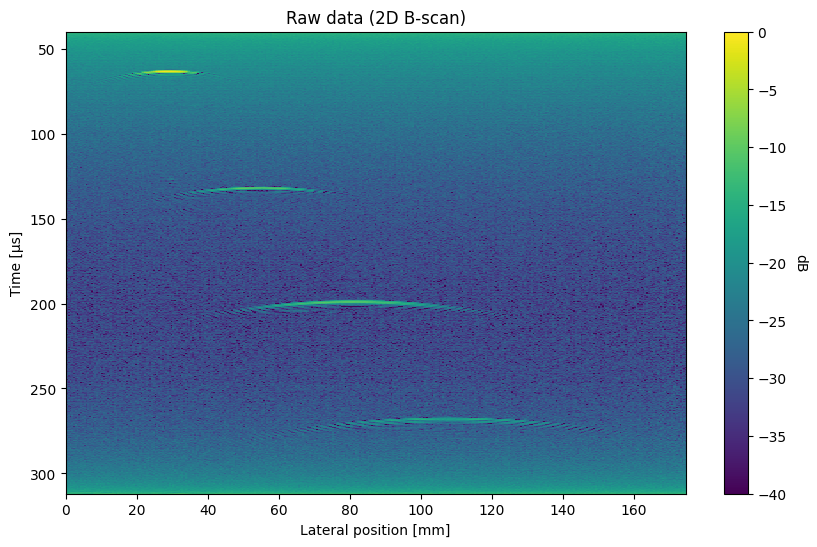

In [4]:
# Display raw data
plot_us_image(
    np.abs(hilbert(psm.raw_data, axis=0)),
    x_val=psm.x_vec * 1e3,
    y_val=psm.time_vec * 1e6,
    title="Raw data (2D B-scan)",
    x_label="Lateral position [mm]",
    y_label="Time [µs]",
    min_db=-40,
    figsize=(10, 6),
)

In [5]:
# Run migration (focus image)
images, z_vecs = psm.phase_shift_migrate()

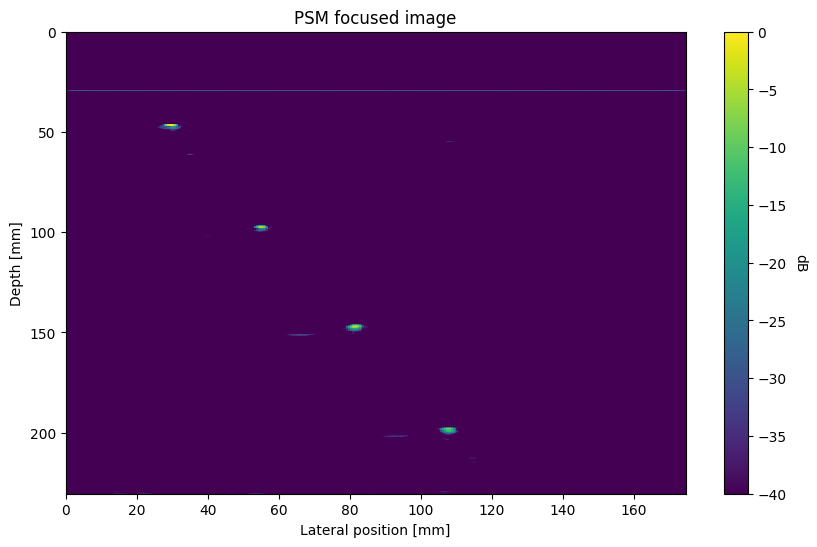

In [ ]:
# Plot focused image
plot_us_image(
    images[0],
    x_val=psm.x_vec * 1e3,
    y_val=z_vecs[0] * 1e3,
    min_db=-40,
    figsize=(10, 6),
    title="PSM focused image",
    x_label="Lateral position [mm]",
    y_label="Depth [mm]",
)